In [368]:
!pip install yfinance --upgrade --no-cache-dir

In [369]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

In [370]:
def compute_macd(
    df: pd.DataFrame,
    fast: int = 12,
    slow: int = 26,
    signal: int = 9,
    price_col: str | None = None,
):
    """
    Compute MACD, Signal line, and Histogram.

    Parameters
    ----------
    df : pd.DataFrame
        OHLCV dataframe
    fast : int
        Fast EMA period (default 12)
    slow : int
        Slow EMA period (default 26)
    signal : int
        Signal EMA period (default 9)
    price_col : str | None
        Column to use as price. If None, auto-detects 'close' or 'Close'.

    Returns
    -------
    pd.DataFrame
        DataFrame with columns:
        - macd
        - macd_signal
        - macd_hist
    """

    # ---- Detect price column safely ----
    if price_col is None:
        if "close" in df.columns:
            price = df["close"]
        elif "Close" in df.columns:
            price = df["Close"]
        else:
            raise KeyError("No 'close' or 'Close' column found in dataframe")
    else:
        if price_col not in df.columns:
            raise KeyError(f"'{price_col}' not found in dataframe")
        price = df[price_col]

    # ---- EMAs ----
    ema_fast = price.ewm(span=fast, adjust=False).mean()
    ema_slow = price.ewm(span=slow, adjust=False).mean()

    macd = ema_fast - ema_slow
    macd_signal = macd.ewm(span=signal, adjust=False).mean()
    macd_hist = macd - macd_signal

    df["macd"] = macd
    df["macd_signal"] = macd_signal
    df["macd_hist"] = macd_hist

In [371]:
def add_rsi(
    df: pd.DataFrame,
    period: int = 14,
    price_col: str | None = None,
    col_name: str = "rsi",
) -> pd.DataFrame:
    """
    Calculate Wilder's RSI and add it as a column to the dataframe.

    Parameters
    ----------
    df : pd.DataFrame
        OHLCV dataframe
    period : int
        RSI period (default 14)
    price_col : str | None
        Column to use as price. If None, auto-detects 'close' or 'Close'.
    col_name : str
        Name of RSI column to add

    Returns
    -------
    pd.DataFrame
        Original dataframe with RSI column added
    """

    # ---- Detect price column ----
    if price_col is None:
        if "close" in df.columns:
            price = df["close"]
        elif "Close" in df.columns:
            price = df["Close"]
        else:
            raise KeyError("No 'close' or 'Close' column found in dataframe")
    else:
        if price_col not in df.columns:
            raise KeyError(f"'{price_col}' not found in dataframe")
        price = df[price_col]

    # ---- Price differences ----
    delta = price.diff()

    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)

    # ---- Wilder smoothing (EMA with alpha = 1/period) ----
    avg_gain = gain.ewm(alpha=1/period, adjust=False).mean()
    avg_loss = loss.ewm(alpha=1/period, adjust=False).mean()

    rs = avg_gain / avg_loss
    rsi = 100 - (100 / (1 + rs))

    df[col_name] = rsi
    return df

In [372]:
def volume_rsi(df, vol_col="Volume", period=14, col_name="vol_rsi"):
    """
    Calculate Volume RSI (VRSI) using Wilder's smoothing.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame containing volume data
    vol_col : str
        Column name for volume
    period : int
        RSI lookback period
    col_name : str
        Name of output column

    Returns
    -------
    pd.DataFrame
        DataFrame with Volume RSI column added
    """

    delta = df[vol_col].diff()

    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)

    avg_gain = gain.ewm(alpha=1/period, adjust=False).mean()
    avg_loss = loss.ewm(alpha=1/period, adjust=False).mean()

    rs = avg_gain / avg_loss
    df[col_name] = 100 - (100 / (1 + rs))

    return df


In [373]:
def calculate_atr(
    df,
    high_col="High",
    low_col="Low",
    close_col="Close",
    period=14,
    col_name="atr"
):
    """
    Calculate Average True Range (ATR) using Wilder's smoothing.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame containing OHLC data
    high_col : str
        High price column
    low_col : str
        Low price column
    close_col : str
        Close price column
    period : int
        ATR lookback period
    col_name : str
        Name of output ATR column

    Returns
    -------
    pd.DataFrame
        DataFrame with ATR column added
    """

    high = df[high_col]
    low = df[low_col]
    close = df[close_col]

    prev_close = close.shift(1)

    tr = pd.concat(
        [
            high - low,
            (high - prev_close).abs(),
            (low - prev_close).abs(),
        ],
        axis=1
    ).max(axis=1)

    atr = tr.ewm(alpha=1/period, adjust=False).mean()

    df[col_name] = atr
    return df


In [374]:
def calculate_vwap(
    df,
    high_col="High",
    low_col="Low",
    close_col="Close",
    volume_col="Volume",
    date_col=None,
    col_name="vwap"
):
    """
    Calculate VWAP (Volume Weighted Average Price).

    If date_col is provided, VWAP resets every day (intraday VWAP).
    If date_col is None, VWAP is calculated cumulatively.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame containing OHLCV data
    high_col, low_col, close_col : str
        OHLC column names
    volume_col : str
        Volume column name
    date_col : str or None
        Column to group by (e.g. date)
    col_name : str
        Output column name

    Returns
    -------
    pd.DataFrame
        DataFrame with VWAP column added
    """

    typical_price = (df[high_col] + df[low_col] + df[close_col]) / 3
    pv = typical_price * df[volume_col]

    if date_col:
        cum_pv = pv.groupby(df[date_col]).cumsum()
        cum_vol = df[volume_col].groupby(df[date_col]).cumsum()
        df[col_name] = cum_pv / cum_vol
    else:
        df[col_name] = pv.cumsum() / df[volume_col].cumsum()

    return df


In [375]:
def make_features(df: pd.DataFrame):
  df = df.copy()
  df = df[df["Volume"]>0]
  df["rel_volume"] = df["Volume"] / df["Volume"].rolling(20).mean()
  df["hl_range"] = (df["High"] - df["Low"]) / df["Close"].shift(1)
  df["oc_gap"]   = (df["Open"] - df["Close"].shift(1)) / df["Close"].shift(1)
  df["sma_5"]  = df["Close"].rolling(5).mean()
  df["sma_10"] = df["Close"].rolling(10).mean()
  df["sma_ratio"] = df["sma_5"] / df["sma_10"] - 1.0
  df = volume_rsi(df)
  df = calculate_atr(df)
  df = calculate_vwap(df)
  df["volatility"] = df["atr"] / df["Close"]
  vol_floor = 1e-4  # prevents blow-ups
  df["vol_adj"] = df["volatility"].clip(lower=vol_floor)
  df["ret"] = df["Close"].pct_change().shift(-1)
  df["Direction"] = (df["Close"].shift(-1) > df["Close"]).astype(int)
  return df

In [376]:
model = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=100, class_weight="balanced"))
    ])

In [377]:
ircon= yf.Ticker("IRCON.NS")
ircon_history = ircon.history(start="2025-10-01", end="2025-12-31", interval="1d")
train = ircon_history.drop(columns = ["Dividends","Stock Splits"])
#train = pd.read_csv("ircon.csv")
train = make_features(train)
compute_macd(train)
add_rsi(train)
train.drop(train.index[0:21], inplace=True)

FEATURE_COLS = ["Open","Close","macd_hist","rsi","atr","vol_rsi"]
X_train = train[FEATURE_COLS]
y_train = train["Direction"]

print(train.columns.values)
#train.plot(x=train.index.values,y=["Open","Close","High","Low","Volume","rel_volume","hl_range","oc_gap","sma_5","sma_10","sma_ratio","macd","macd_signal","macd_hist"],kind = "line")
model.fit(X_train,y_train)
train

['Open' 'High' 'Low' 'Close' 'Volume' 'rel_volume' 'hl_range' 'oc_gap'
 'sma_5' 'sma_10' 'sma_ratio' 'vol_rsi' 'atr' 'vwap' 'volatility'
 'vol_adj' 'ret' 'Direction' 'macd' 'macd_signal' 'macd_hist' 'rsi']


,Open,High,Low,Close,Volume,rel_volume,hl_range,oc_gap,sma_5,sma_10,...,atr,vwap,volatility,vol_adj,ret,Direction,macd,macd_signal,macd_hist,rsi
Date,,,,,,,,,,,,,,,,,,,,,
2025-11-03 00:00:00+05:30,169.509995,171.720001,169.000000,169.380005,1253481,0.545438,0.016036,-0.000649,170.378000,170.238000,...,3.471733,174.604848,0.020497,0.020497,-0.007203,0,-1.126063,-0.923591,-0.202472,49.900090
2025-11-04 00:00:00+05:30,169.630005,169.889999,167.470001,168.160004,1387725,0.602272,0.014287,0.001476,170.270001,170.031001,...,3.396609,174.439071,0.020199,0.020199,-0.027474,0,-1.261372,-0.991147,-0.270225,47.020027
2025-11-06 00:00:00+05:30,168.440002,168.440002,162.500000,163.539993,2004456,1.065574,0.035324,0.001665,168.534000,169.309001,...,3.578280,174.075889,0.021880,0.021880,0.000367,1,-1.721557,-1.137229,-0.584328,38.061213
2025-11-07 00:00:00+05:30,162.899994,164.000000,159.710007,163.600006,1578924,0.905684,0.026232,-0.003913,166.860001,168.725002,...,3.629117,173.739498,0.022183,0.022183,-0.004034,0,-2.057694,-1.321322,-0.736372,38.225862
2025-11-10 00:00:00+05:30,164.199997,164.800003,162.550003,162.940002,822240,0.493672,0.013753,0.003667,165.524002,168.037001,...,3.530609,173.586634,0.021668,0.021668,0.008776,1,-2.350250,-1.527108,-0.823142,37.059108
2025-11-11 00:00:00+05:30,163.100006,165.199997,162.160004,164.369995,1194097,0.729503,0.018657,0.000982,164.522000,167.450000,...,3.495565,173.382656,0.021266,0.021266,0.012654,1,-2.438604,-1.709407,-0.729197,41.243660
2025-11-12 00:00:00+05:30,165.000000,167.850006,163.600006,166.449997,1530553,0.929838,0.025856,0.003833,164.179999,167.225000,...,3.549453,173.187556,0.021324,0.021324,-0.031962,0,-2.314110,-1.830347,-0.483762,46.785577
2025-11-13 00:00:00+05:30,161.050003,164.000000,160.630005,161.130005,3783077,2.153828,0.020246,-0.032442,163.698001,166.116000,...,3.711634,172.499610,0.023035,0.023035,0.013281,1,-2.614587,-1.987195,-0.627392,37.137339
2025-11-14 00:00:00+05:30,161.199997,167.800003,161.199997,163.270004,4180743,2.229946,0.040961,0.000434,163.632001,165.246001,...,3.922946,171.968050,0.024027,0.024027,0.031972,1,-2.649496,-2.119656,-0.529841,42.292646


<Axes: xlabel='Date'>

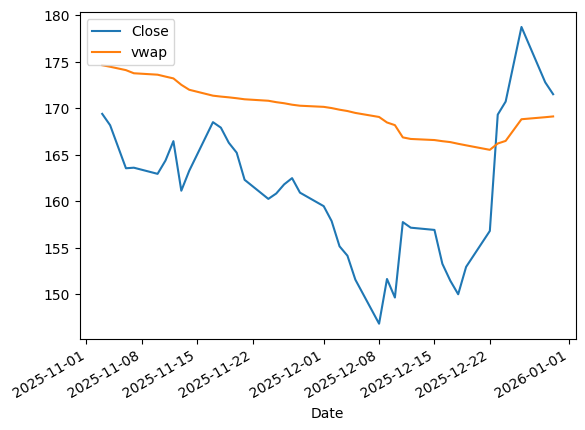

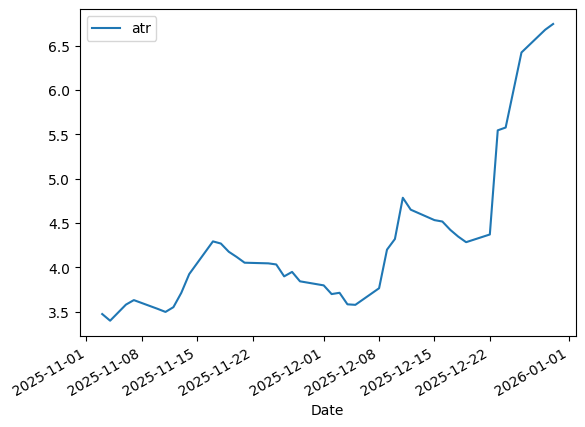

In [378]:
train.plot(y=["Close","vwap"])
train.plot(y=["atr"])

In [379]:
ircon_test = ircon.history(start="2025-12-04", end="2026-01-08", interval="1d")
test = ircon_test.drop(columns = ["Dividends","Stock Splits"])
test = make_features(test)
compute_macd(test)
add_rsi(test)
test.drop(test.index[0:19], inplace=True)

X_test = test[FEATURE_COLS]
y_test = test["Direction"]

In [380]:
predictions = model.predict(X_train)
train["Prediction"] = predictions
Prob = model.predict_proba(X_train)
Up_Prob = np.zeros(len((X_train)))

for i, prob in enumerate(Prob):
  Up_Prob[i] = prob[1]

train["Up_Prob"] = Up_Prob


In [381]:
long_th = 0.55
short_th = 0.45

train["signal"] = np.where(
    train["Up_Prob"] >= long_th,  1,
    np.where(train["Up_Prob"] <= short_th, -1, 0)
)

train["position"] = train["signal"] / train["vol_adj"]
max_leverage = 1.0

#train["position"] = train["position"] / train["position"].abs().rolling(20).mean()
train["position"] = train["position"].clip(-max_leverage, max_leverage)

#test["signal"] = np.array([1,-1,1,1,1])

train["strategy_ret"] = train["position"] * train["ret"]
train["equity"] = (1 + train["strategy_ret"]).cumprod()
train = train.dropna()
total_pnl = train["equity"].iloc[-1] - 1
sharpe = (
    train["strategy_ret"].mean()*np.sqrt(252)
    / train["strategy_ret"].std()
)
rolling_max = train["equity"].cummax()
drawdown = train["equity"] / rolling_max - 1
max_drawdown = drawdown.min()

results = {
    "Total PnL (%)": round(total_pnl * 100, 2),
    "Sharpe Ratio": round(sharpe, 2),
    "Max Drawdown (%)": round(max_drawdown * 100, 2),
}

results


{'Total PnL (%)': np.float64(33.24),
 'Sharpe Ratio': np.float64(5.6),
 'Max Drawdown (%)': -5.36}

In [382]:
predictions = model.predict(X_test)
test["Prediction"] = predictions
Prob = model.predict_proba(X_test)
Up_Prob = np.zeros(len((X_test)))

for i, prob in enumerate(Prob):
  Up_Prob[i] = prob[1]

test["Up_Prob"] = Up_Prob
test

,Open,High,Low,Close,Volume,rel_volume,hl_range,oc_gap,sma_5,sma_10,...,volatility,vol_adj,ret,Direction,macd,macd_signal,macd_hist,rsi,Prediction,Up_Prob
Date,,,,,,,,,,,,,,,,,,,,,
2026-01-01 00:00:00+05:30,177.600006,179.690002,175.509995,177.979996,3712327,0.401516,0.023529,-0.000281,175.720001,167.837000,...,0.035346,0.035346,0.006967,1,5.953706,3.606598,2.347108,58.332159,0,0.202473
2026-01-02 00:00:00+05:30,178.770004,182.369995,177.910004,179.220001,6334893,0.665581,0.025059,0.004439,175.822000,170.758000,...,0.034372,0.034372,-0.012275,0,6.387686,4.162816,2.224871,59.413479,0,0.202124
2026-01-05 00:00:00+05:30,179.220001,180.800003,176.220001,177.020004,2913926,0.303329,0.025555,0.000000,176.672000,173.165001,...,0.034161,0.034161,0.001356,1,6.479408,4.626134,1.853274,56.606726,0,0.210224
2026-01-06 00:00:00+05:30,177.399994,181.529999,175.800003,177.259995,4488652,0.461327,0.032369,0.002147,177.825998,175.210001,...,0.033987,0.033987,0.000903,1,6.496574,5.000222,1.496352,56.846220,0,0.223876
2026-01-07 00:00:00+05:30,177.259995,179.449997,175.860001,177.419998,2786316,0.286777,0.020253,0.000000,177.779999,176.022000,...,0.032976,0.032976,NaN,0,6.448752,5.289928,1.158824,57.016551,0,0.227081


In [383]:
long_th = 0.55
short_th = 0.45

test["signal"] = np.where(
    test["Up_Prob"] >= long_th,  1,
    np.where(test["Up_Prob"] <= short_th, -1, 0)
)

#test["signal"] = np.array([1,-1,1,1,1])
test["position"] = test["signal"] / test["vol_adj"]
max_leverage = 1.0

#test["position"] = test["position"] / test["position"].abs().rolling(20).mean()
test["position"] = test["position"].clip(-max_leverage, max_leverage)

test["strategy_ret"] = test["position"] * test["ret"]
test["equity"] = (1 + test["strategy_ret"]).cumprod()
print(test)
test = test.dropna()
total_pnl = test["equity"].iloc[-1] - 1
sharpe = (
    test["strategy_ret"].mean()*np.sqrt(252)
    / test["strategy_ret"].std()
)
rolling_max = test["equity"].cummax()
drawdown = test["equity"] / rolling_max - 1
max_drawdown = drawdown.min()

results = {
    "Total PnL (%)": round(total_pnl * 100, 2),
    "Sharpe Ratio": round(sharpe, 2),
    "Max Drawdown (%)": round(max_drawdown * 100, 2),
}

results


                                 Open        High         Low       Close  \
Date                                                                        
2026-01-01 00:00:00+05:30  177.600006  179.690002  175.509995  177.979996   
2026-01-02 00:00:00+05:30  178.770004  182.369995  177.910004  179.220001   
2026-01-05 00:00:00+05:30  179.220001  180.800003  176.220001  177.020004   
2026-01-06 00:00:00+05:30  177.399994  181.529999  175.800003  177.259995   
2026-01-07 00:00:00+05:30  177.259995  179.449997  175.860001  177.419998   

                            Volume  rel_volume  hl_range    oc_gap  \
Date                                                                 
2026-01-01 00:00:00+05:30  3712327    0.401516  0.023529 -0.000281   
2026-01-02 00:00:00+05:30  6334893    0.665581  0.025059  0.004439   
2026-01-05 00:00:00+05:30  2913926    0.303329  0.025555  0.000000   
2026-01-06 00:00:00+05:30  4488652    0.461327  0.032369  0.002147   
2026-01-07 00:00:00+05:30  2786316    0.

{'Total PnL (%)': np.float64(0.3),
 'Sharpe Ratio': np.float64(1.48),
 'Max Drawdown (%)': -0.23}